In [1]:
!pip install tensorflow

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import random
import os

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

from tensorflow.keras import layers, models, regularizers, initializers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [6]:
X_test_processed = pd.read_csv('/content/drive/MyDrive/Customer-Churn-Prediction-ANN/data/proccessed/X_test_processed.csv')
X_train_processed = pd.read_csv('/content/drive/MyDrive/Customer-Churn-Prediction-ANN/data/proccessed/X_train_processed.csv')
y_test_processed = pd.read_csv('/content/drive/MyDrive/Customer-Churn-Prediction-ANN/data/proccessed/y_test_processed.csv')
y_train_processed = pd.read_csv('/content/drive/MyDrive/Customer-Churn-Prediction-ANN/data/proccessed/y_train_processed.csv')

label_encoder = joblib.load('/content/drive/MyDrive/Customer-Churn-Prediction-ANN/models/label_encoder.pkl')
scaler = joblib.load('/content/drive/MyDrive/Customer-Churn-Prediction-ANN/models/scaler.pkl')

In [7]:
def build_ann(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(64, activation='relu',
                     kernel_initializer=initializers.HeNormal(seed=SEED),
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.30),

        layers.Dense(32, activation='relu',
                     kernel_initializer=initializers.HeNormal(seed=SEED),
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.20),

        layers.Dense(16, activation='relu',
                     kernel_initializer=initializers.HeNormal(seed=SEED)),

        layers.Dense(1, activation='sigmoid')
    ])
    return model

model = build_ann(input_dim=X_train_processed.shape[1])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,777 (14.75 KB)

 Trainable params: 3,585 (14.00 KB)

 Non-trainable params: 192 (768.00 B)

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

In [9]:
os.makedirs('models', exist_ok=True)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath='models/ann_churn_best.h5',
    monitor='val_auc',
    mode='max',
    save_best_only=True,
    verbose=1
)

callbacks_list = [early_stop, reduce_lr, checkpoint]

In [10]:
history = model.fit(
    X_train_processed, y_train_processed,
    validation_split=0.2,
    epochs=150,
    batch_size=32,
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/150
191/200 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7297 - auc: 0.5939 - loss: 0.7986 - precision: 0.3185 - recall: 0.2319
Epoch 1: val_auc improved from None to 0.75997, saving model to models/ann_churn_best.h5



Epoch 1: finished saving model to models/ann_churn_best.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7634 - auc: 0.6389 - loss: 0.7223 - precision: 0.3571 - recall: 0.1947 - val_accuracy: 0.7994 - val_auc: 0.7600 - val_loss: 0.6199 - val_precision: 0.4971 - val_recall: 0.2656 - learning_rate: 0.0010
Epoch 2/150
186/200 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7803 - auc: 0.7098 - loss: 0.6575 - precision: 0.4422 - recall: 0.1596
Epoch 2: val_auc improved from 0.75997 to 0.79476, saving model to models/ann_churn_best.h5



Epoch 2: finished saving model to models/ann_churn_best.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7909 - auc: 0.7258 - loss: 0.6352 - precision: 0.4693 - recall: 0.1634 - val_accuracy: 0.8225 - val_auc: 0.7948 - val_loss: 0.5778 - val_precision: 0.6429 - val_recall: 0.2531 - learning_rate: 0.0010
Epoch 3/150
189/200 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7904 - auc: 0.7477 - loss: 0.6185 - precision: 0.5039 - recall: 0.1915
Epoch 3: val_auc improved from 0.79476 to 0.82094, saving model to models/ann_churn_best.h5



Epoch 3: finished saving model to models/ann_churn_best.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8039 - auc: 0.7599 - loss: 0.6006 - precision: 0.5547 - recall: 0.2130 - val_accuracy: 0.8481 - val_auc: 0.8209 - val_loss: 0.5449 - val_precision: 0.7305 - val_recall: 0.3812 - learning_rate: 0.0010
Epoch 4/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8131 - auc: 0.7764 - loss: 0.5847 - precision: 0.6239 - recall: 0.2756
Epoch 4: val_auc improved from 0.82094 to 0.83828, saving model to models/ann_churn_best.h5



Epoch 4: finished saving model to models/ann_churn_best.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8133 - auc: 0.7833 - loss: 0.5719 - precision: 0.5932 - recall: 0.2794 - val_accuracy: 0.8600 - val_auc: 0.8383 - val_loss: 0.5154 - val_precision: 0.7637 - val_recall: 0.4344 - learning_rate: 0.0010
Epoch 5/150
198/200 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8125 - auc: 0.7911 - loss: 0.5632 - precision: 0.6122 - recall: 0.2993
Epoch 5: val_auc improved from 0.83828 to 0.84671, saving model to models/ann_churn_best.h5


...


Epoch 15: finished saving model to models/ann_churn_best.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8498 - auc: 0.8485 - loss: 0.4225 - precision: 0.7146 - recall: 0.4435 - val_accuracy: 0.8694 - val_auc: 0.8661 - val_loss: 0.3926 - val_precision: 0.7681 - val_recall: 0.4969 - learning_rate: 0.0010
Epoch 16/150
188/200 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8412 - auc: 0.8534 - loss: 0.4246 - precision: 0.6988 - recall: 0.4311
Epoch 16: val_auc did not improve from 0.86611
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8447 - auc: 0.8484 - loss: 0.4199 - precision: 0.6913 - recall: 0.4359 - val_accuracy: 0.8731 - val_auc: 0.8638 - val_loss: 0.3895 - val_precision: 0.7854 - val_recall: 0.5031 - learning_rate: 0.0010
Epoch 17/150
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8468 - auc: 0.8538 - loss: 0.4165 - precision: 0.7170 - recall: 0.4475
Epoch 17: val_auc improved from 0.86611 to 0.86641, saving model to models/ann_churn_best.h5



Epoch 17: finished saving model to models/ann_churn_best.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8500 - auc: 0.8480 - loss: 0.4136 - precision: 0.7114 - recall: 0.4496 - val_accuracy: 0.8650 - val_auc: 0.8664 - val_loss: 0.3823 - val_precision: 0.7301 - val_recall: 0.5156 - learning_rate: 0.0010
Epoch 18/150
196/200 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8436 - auc: 0.8537 - loss: 0.4141 - precision: 0.7078 - recall: 0.4382
Epoch 18: val_auc improved from 0.86641 to 0.86761, saving model to models/ann_churn_best.h5



Epoch 18: finished saving model to models/ann_churn_best.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8489 - auc: 0.8537 - loss: 0.4059 - precision: 0.7025 - recall: 0.4542 - val_accuracy: 0.8650 - val_auc: 0.8676 - val_loss: 0.3784 - val_precision: 0.7549 - val_recall: 0.4812 - learning_rate: 0.0010
Epoch 19/150
195/200 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8430 - auc: 0.8567 - loss: 0.4071 - precision: 0.7149 - recall: 0.4253
Epoch 19: val_auc improved from 0.86761 to 0.86866, saving model to models/ann_churn_best.h5



Epoch 19: finished saving model to models/ann_churn_best.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8467 - auc: 0.8496 - loss: 0.4062 - precision: 0.7038 - recall: 0.4336 - val_accuracy: 0.8662 - val_auc: 0.8687 - val_loss: 0.3733 - val_precision: 0.7500 - val_recall: 0.4969 - learning_rate: 0.0010
Epoch 20/150
190/200 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8366 - auc: 0.8556 - loss: 0.4080 - precision: 0.6824 - recall: 0.4225
Epoch 20: val_auc improved from 0.86866 to 0.86895, saving model to models/ann_churn_best.h5



Epoch 20: finished saving model to models/ann_churn_best.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8464 - auc: 0.8567 - loss: 0.3983 - precision: 0.6982 - recall: 0.4397 - val_accuracy: 0.8631 - val_auc: 0.8690 - val_loss: 0.3715 - val_precision: 0.7371 - val_recall: 0.4906 - learning_rate: 0.0010
Epoch 21/150
195/200 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8462 - auc: 0.8574 - loss: 0.4010 - precision: 0.7073 - recall: 0.4584
Epoch 21: val_auc did not improve from 0.86895
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8502 - auc: 0.8588 - loss: 0.3933 - precision: 0.7082 - recall: 0.4557 - val_accuracy: 0.8625 - val_auc: 0.8669 - val_loss: 0.3724 - val_precision: 0.7273 - val_recall: 0.5000 - learning_rate: 0.0010
Epoch 22/150
187/200 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8473 - auc: 0.8641 - loss: 0.3933 - precision: 0.7119 - recall: 0.4644
Epoch 22: val_auc did not improve from 0.86895
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.85

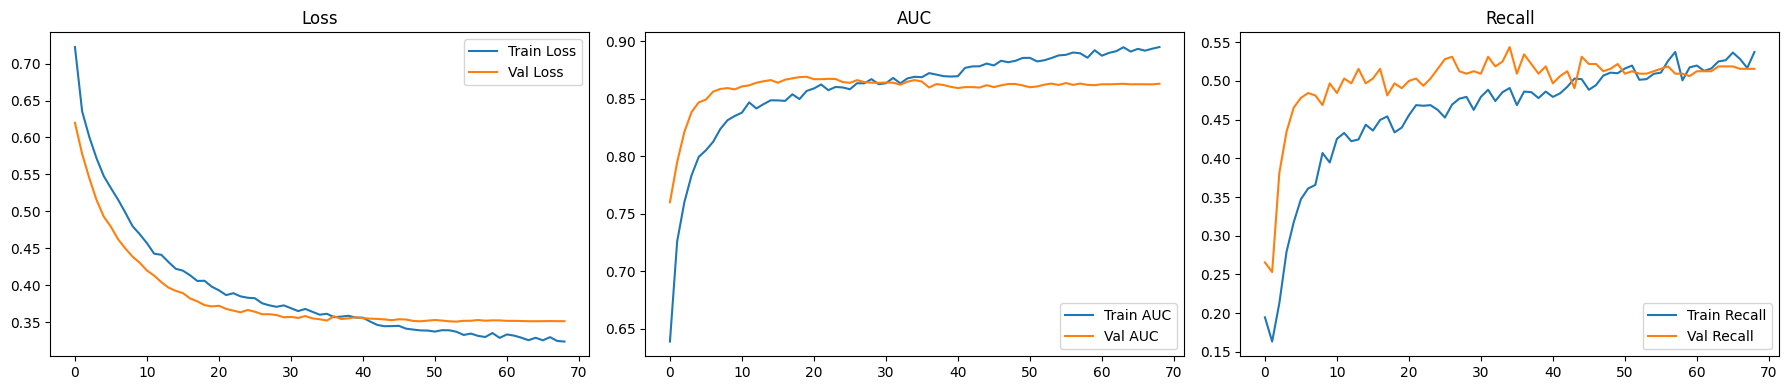

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history.history['auc'], label='Train AUC')
axes[1].plot(history.history['val_auc'], label='Val AUC')
axes[1].set_title('AUC')
axes[1].legend()

axes[2].plot(history.history['recall'], label='Train Recall')
axes[2].plot(history.history['val_recall'], label='Val Recall')
axes[2].set_title('Recall')
axes[2].legend()

plt.tight_layout()
plt.savefig('training_history.png')
plt.show()

In [16]:
y_pred_prob = model.predict(X_test_processed).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

print("Accuracy :", accuracy_score(y_test_processed, y_pred))
print("Precision:", precision_score(y_test_processed, y_pred))
print("Recall   :", recall_score(y_test_processed, y_pred))
print("F1 Score :", f1_score(y_test_processed, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test_processed, y_pred_prob))
print("\nClassification Report:\n", classification_report(y_test_processed, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Accuracy : 0.869
Precision: 0.7474402730375427
Recall   : 0.538083538083538
F1 Score : 0.6257142857142857
ROC-AUC  : 0.8580151800490783

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.95      0.92      1593
           1       0.75      0.54      0.63       407

    accuracy                           0.87      2000
   macro avg       0.82      0.75      0.77      2000
weighted avg       0.86      0.87      0.86      2000



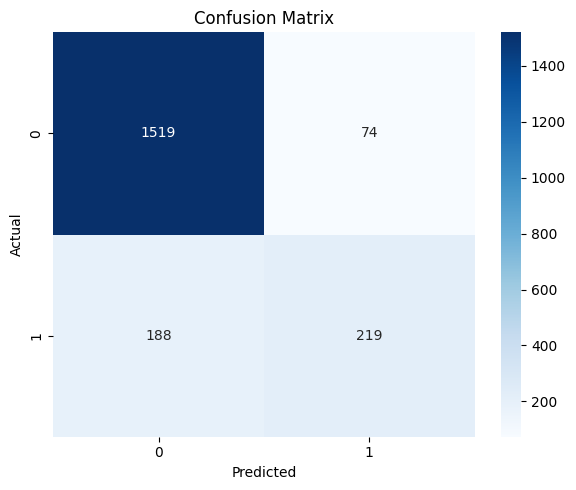

In [18]:
fig, ax = plt.subplots(figsize=(6, 5))

# Confusion Matrix
cm = confusion_matrix(y_test_processed, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

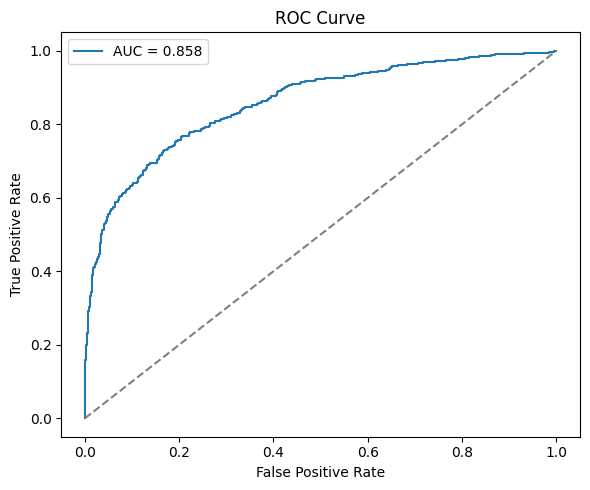

In [19]:
fig, ax = plt.subplots(figsize=(6, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_processed, y_pred_prob)
ax.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test_processed, y_pred_prob):.3f}')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
ax.set_title('ROC Curve')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()

plt.tight_layout()
plt.savefig('roc_curve.png')
plt.show()

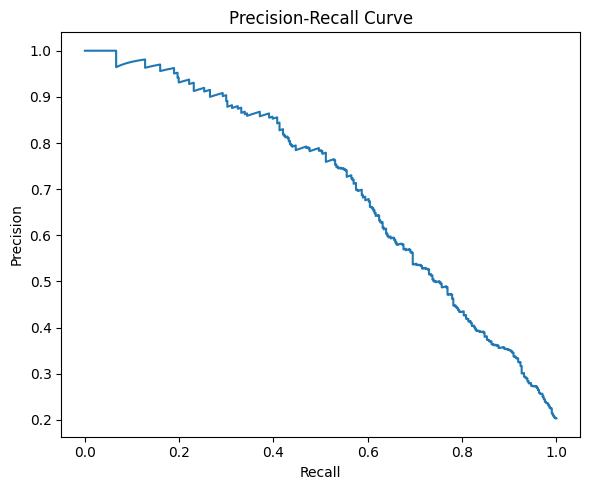

In [20]:
fig, ax = plt.subplots(figsize=(6, 5))

# Precision-Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test_processed, y_pred_prob)
ax.plot(recall_vals, precision_vals)
ax.set_title('Precision-Recall Curve')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')

plt.tight_layout()
plt.savefig('precision_recall_curve.png')
plt.show()

In [22]:
model.save('ann_churn_baseline.h5')#models
print("Model saved to models/ann_churn_baseline.h5")

ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=ann_churn_baseline.pkl.